In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import folium

In [4]:
# load files
audio_df = pd.read_excel("loc_audio.xlsx")  
video_df = pd.read_excel("loc_video.xlsx") 

print("Audio:", audio_df.columns)
print("Video:", video_df.columns)

Audio: Index(['ID', 'Latitude', 'Longitude', 'Elevation'], dtype='object')
Video: Index(['ID', 'Found on', 'Latitude', 'Longitude', 'Elevation'], dtype='object')


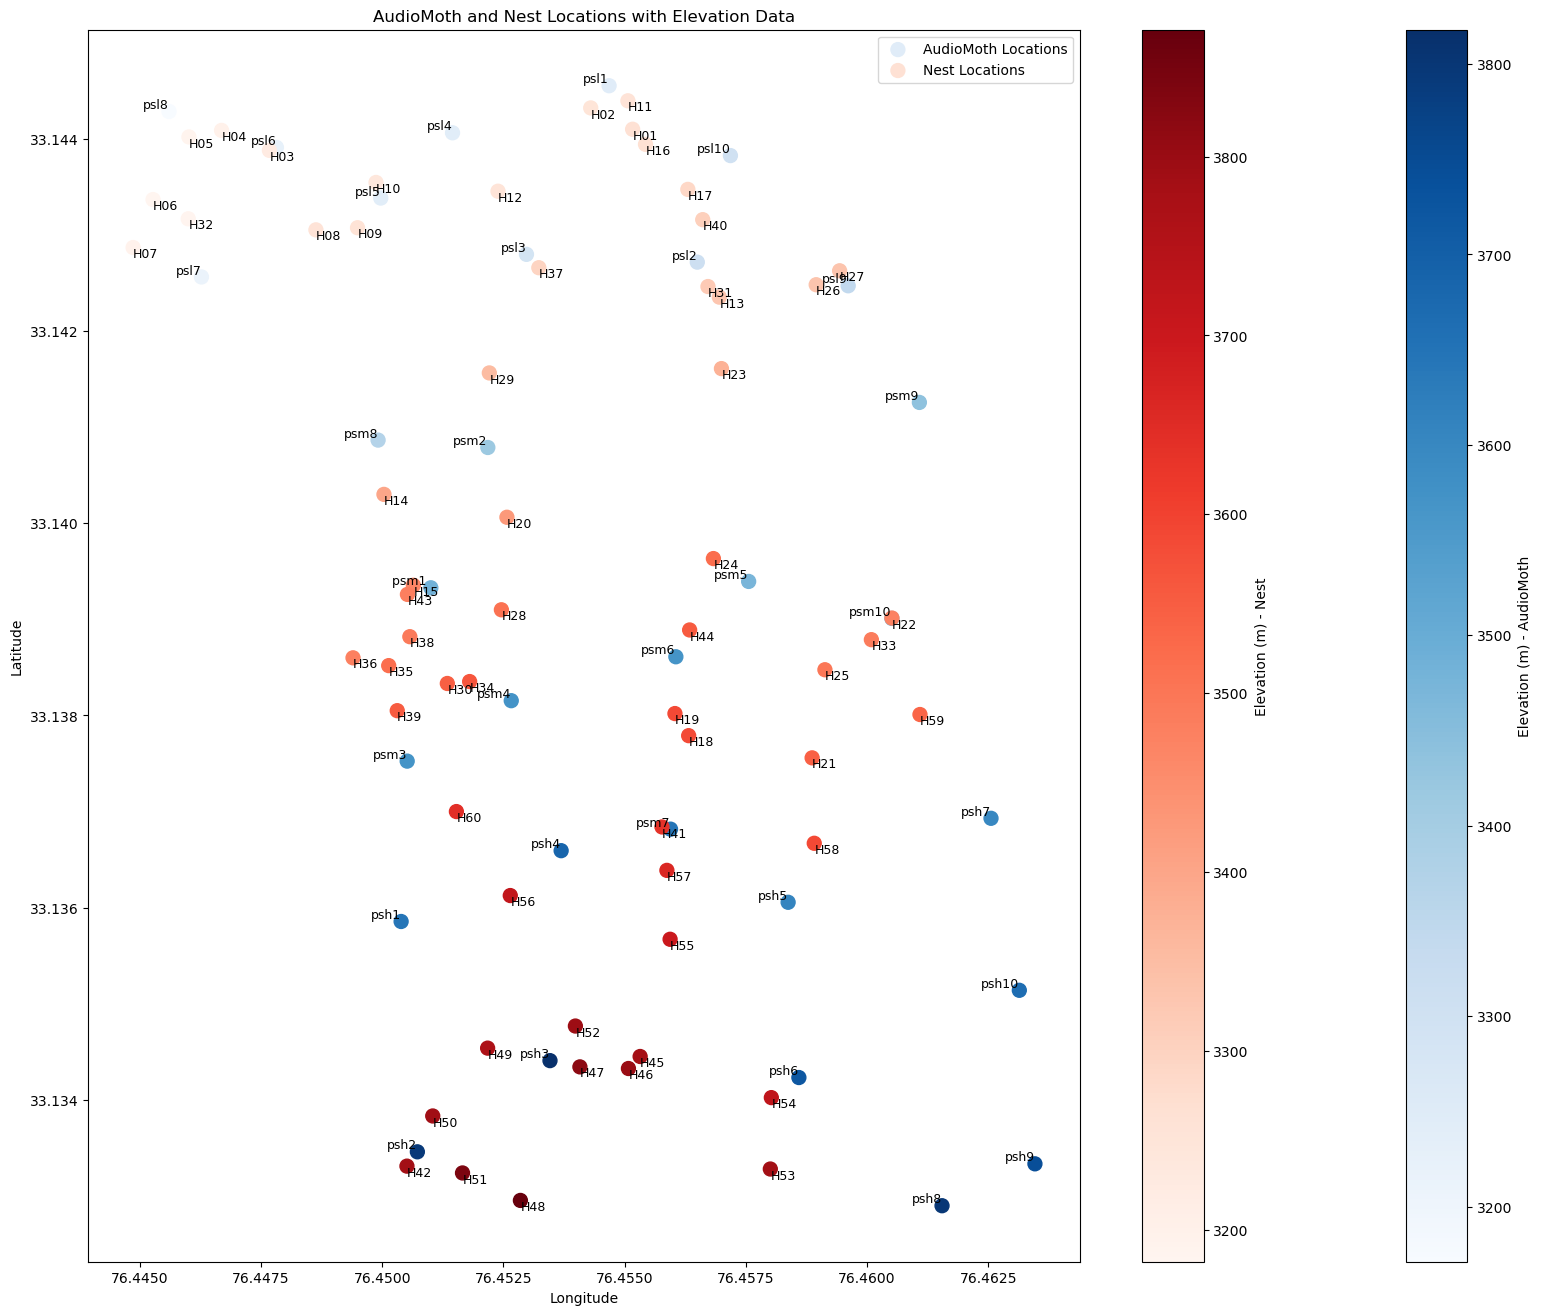

In [5]:
# create a scatter plot with elevation represented by color
plt.figure(figsize=(20, 16))


audio_plot = plt.scatter(audio_df["Longitude"], audio_df["Latitude"], c=audio_df["Elevation"], 
                         cmap="Blues", s=100, label="AudioMoth Locations") # edgecolor="black"

video_plot = plt.scatter(video_df["Longitude"], video_df["Latitude"], c=video_df["Elevation"], 
                         cmap="Reds", s=100, label="Nest Locations") # edgecolor="black"

# add color bars for elevation
plt.colorbar(audio_plot, label="Elevation (m) - AudioMoth", orientation="vertical")
plt.colorbar(video_plot, label="Elevation (m) - Nest", orientation="vertical")

# add labels to each point
for i in range(len(audio_df)):
    plt.text(audio_df["Longitude"][i], audio_df["Latitude"][i], audio_df["ID"][i], fontsize=9, ha='right', va='bottom', color="black")

for i in range(len(video_df)):
    plt.text(video_df["Longitude"][i], video_df["Latitude"][i], video_df["ID"][i], fontsize=9, ha='left', va='top', color="black")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("AudioMoth and Nest Locations with Elevation Data")
plt.legend()


# saving the plot
plt.savefig("audio_video_map.png")
plt.show()


In [12]:

# Create a map centered around the first point
map_center = [33.144554, 76.454679]
map = folium.Map(location=map_center, zoom_start=15)

# Add markers with the IDs and Elevation info
for _, location in audio_df.iterrows():  
    folium.Marker(
        location=[location["Latitude"], location["Longitude"]],
        popup=f"Mic: {location['ID']}<br>Elevation: {location['Elevation']} meters",
        icon=folium.Icon(color="blue")
    ).add_to(map)
    
for _, location in video_df.iterrows():
    folium.Marker(
        location=[location["Latitude"], location["Longitude"]],
        popup=f"Nest: {location['ID']}<br>Found: {location['Found on']}<br>Elevation: {location['Elevation']} meters",
        icon=folium.Icon(color="red")  # Red color for the marker
    ).add_to(map)

# Save the map as an HTML file
map.save('google_map.html')
